# Entanglement versus noise

Create a Bell pair: two qubits whose measurements agree even though each qubit's result is random. Compare an ideal simulator with a noisy simulator. This demo runs locally and needs no hardware token.

Run from the repository with `uv run jupyter lab`, then open this notebook and run all cells.

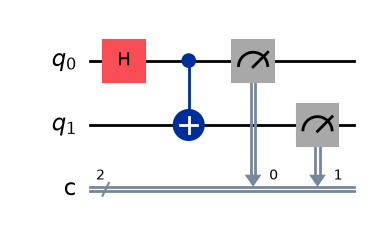

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
from IPython.display import display

SHOTS = 4096
SEED = 2026
NOISE_STRENGTH = 0.15  # Try 0.0, 0.05, and 0.30.

bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])
display(bell.draw(output="mpl"))

The Hadamard gate puts the first qubit into a superposition. The controlled-X gate entangles it with the second qubit. The ideal state is $(|00\rangle + |11\rangle)/\sqrt{2}$. Measuring in this basis gives `00` or `11`, each with about 50% probability.

Matching measurements alone do not prove entanglement: a classical mixture can also agree. The next experiment checks a second basis.

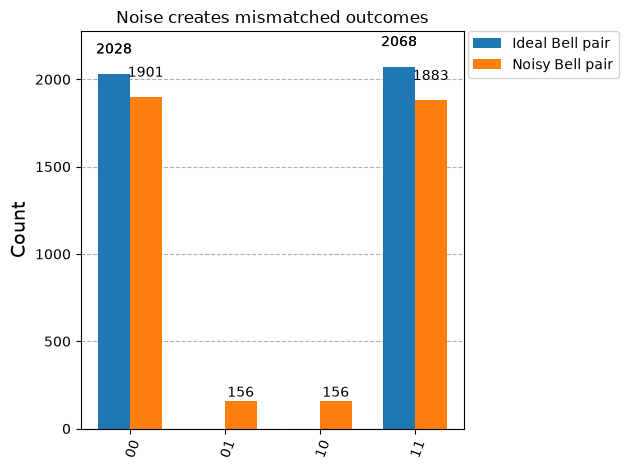

Ideal: 100.0% agreement
Noisy: 92.4% agreement


In [2]:
noise = NoiseModel()
noise.add_all_qubit_quantum_error(depolarizing_error(NOISE_STRENGTH, 2), ["cx"])
ideal_sim = AerSimulator()
noisy_sim = AerSimulator(noise_model=noise)

def sample(circuit, simulator):
    compiled = transpile(circuit, simulator, optimization_level=0, seed_transpiler=SEED)
    return simulator.run(compiled, shots=SHOTS, seed_simulator=SEED).result().get_counts()

ideal_counts = sample(bell, ideal_sim)
noisy_counts = sample(bell, noisy_sim)
display(plot_histogram([ideal_counts, noisy_counts], legend=["Ideal Bell pair", "Noisy Bell pair"], title="Noise creates mismatched outcomes"))

for label, counts in [("Ideal", ideal_counts), ("Noisy", noisy_counts)]:
    agreement = sum(counts.get(key, 0) for key in ["00", "11"]) / SHOTS
    print(f"{label}: {agreement:.1%} agreement")

## Look in a second basis

Applying Hadamard gates before measurement changes the measurement basis from Z to X. The Bell state agrees in both bases. A classical 50/50 mixture of `00` and `11` agrees in Z, but agrees only about half the time in X.

For these states, the witness $\langle ZZ\rangle + \langle XX\rangle > 1$ certifies entanglement in the ideal expectation values. Finite samples fluctuate; a hardware claim would need uncertainty estimates and measurement calibration.

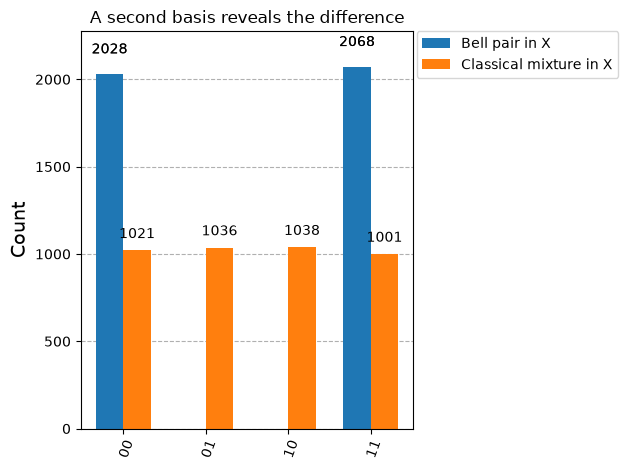

Bell witness ZZ + XX: 2.000 (separable bound: 1)


In [3]:
bell_x = QuantumCircuit(2, 2)
bell_x.h(0)
bell_x.cx(0, 1)
bell_x.h([0, 1])
bell_x.measure([0, 1], [0, 1])

classical_x = QuantumCircuit(2, 2)
# Prepare a classical mixture of |00> and |11> with a density matrix.
import numpy as np
classical_x.set_density_matrix(np.diag([0.5, 0.0, 0.0, 0.5]))
classical_x.h([0, 1])
classical_x.measure([0, 1], [0, 1])

bell_x_counts = sample(bell_x, ideal_sim)
classical_x_counts = sample(classical_x, AerSimulator(method="density_matrix"))
display(plot_histogram([bell_x_counts, classical_x_counts], legend=["Bell pair in X", "Classical mixture in X"], title="A second basis reveals the difference"))

def correlation(counts):
    return (counts.get("00", 0) + counts.get("11", 0) - counts.get("01", 0) - counts.get("10", 0)) / sum(counts.values())

witness = correlation(ideal_counts) + correlation(bell_x_counts)
print(f"Bell witness ZZ + XX: {witness:.3f} (separable bound: 1)")
assert set(ideal_counts) <= {"00", "11"}
assert set(bell_x_counts) <= {"00", "11"}
assert witness > 1


## Try it

Change `NOISE_STRENGTH` and rerun all cells. Increase the shot count to reduce sampling fluctuations. Replace the initial Hadamard gate with `bell.ry(angle, 0)` to explore partially entangled states; make the same preparation change in `bell_x` for a consistent comparison.